In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import shutil
import yaml
import torch
import csv
import random
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import seaborn as sns

Select automatically the most efficient mode for torch

In [10]:
def select_device():
    """
    Select best available device in the following priority:
    1) NVIDIA GPU (CUDA)
    2) Intel GPU (XPU)
    3) CPU
    """
    # NVIDIA GPU
    if torch.cuda.is_available():
        return "cuda"

    # Intel GPU (Xe / Arc, requires Intel Extension for PyTorch)
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        return "xpu"

    # CPU fallback
    return "cpu"

device = select_device()
print(f"Using device: {device}")


Using device: cuda


## Import a pre-trained yolov8 model

In [8]:
# Load model (weights only, device is used at runtime)
model = YOLO("yolov8n.pt")
model.info()
model.names

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

## Model Variations Comparison

We compare three YOLOv8 variants to demonstrate the tradeoff between model size, speed, and accuracy:

In [9]:
# Compare model specifications across YOLOv8 variants
model_specs = {
    'Model': ['YOLOv8n (Nano)', 'YOLOv8s (Small)', 'YOLOv8m (Medium)'],
    'Parameters (M)': [3.2, 11.2, 25.9],
    'GFLOPs': [8.6, 28.6, 78.9],
    'Speed (ms)': [80, 100, 155],
    'Expected mAP': [0.50, 0.58, 0.67],
    'Use Case': ['Real-time, Edge', 'Balanced', 'High Accuracy']
}

specs_df = pd.DataFrame(model_specs)
print("="*80)
print("YOLOv8 MODEL VARIANTS SPECIFICATION COMPARISON")
print("="*80)
print(specs_df.to_string(index=False))
print("\nNotes:")
print("- Parameters: Number of trainable parameters (lower = faster inference)")
print("- GFLOPs: Computational operations (lower = faster training)")
print("- Speed: Average inference time per image on GPU (lower = faster)")
print("- Expected mAP: Approximate mean Average Precision on COCO dataset")
print("\n✅ We selected YOLOv8n for optimal speed-accuracy tradeoff in this project")

YOLOv8 MODEL VARIANTS SPECIFICATION COMPARISON
           Model  Parameters (M)  GFLOPs  Speed (ms)  Expected mAP        Use Case
  YOLOv8n (Nano)             3.2     8.6          80          0.50 Real-time, Edge
 YOLOv8s (Small)            11.2    28.6         100          0.58        Balanced
YOLOv8m (Medium)            25.9    78.9         155          0.67   High Accuracy

Notes:
- Parameters: Number of trainable parameters (lower = faster inference)
- GFLOPs: Computational operations (lower = faster training)
- Speed: Average inference time per image on GPU (lower = faster)
- Expected mAP: Approximate mean Average Precision on COCO dataset

✅ We selected YOLOv8n for optimal speed-accuracy tradeoff in this project


## Train the model on the dataset

In [3]:
import os

# ============================================================
# PATHS (notebooks folder structure)
# ============================================================
# PROJECT_ROOT corresponds to the project root directory.
# The notebook is assumed to be located in: <project_root>/notebooks/
# so we go one level up from the current working directory.
PROJECT_ROOT = os.path.join(os.getcwd(), "..")

# Training images directory
# Expected structure:
# data_processed/
# └── train/
#     └── images/
#         └── <sequence_name>/
#             ├── img00001.jpg
#             └── ...
TRAIN_PATH = os.path.join(PROJECT_ROOT, "data_processed", "train", "images")

# Optional sanity check
assert os.path.isdir(TRAIN_PATH), f"TRAIN_PATH not found: {TRAIN_PATH}"


In [11]:
# ============================================================
# TRAIN / VALIDATION SPLIT BY SEQUENCE (NOT BY IMAGE)
# REPRODUCIBLE VERSION
# ============================================================

train_base = os.path.join(PROJECT_ROOT, "data_processed/train")

sequences = sorted([
    d for d in os.listdir(os.path.join(train_base, "images"))
    if os.path.isdir(os.path.join(train_base, "images", d))
])

# ============================================================
# REPRODUCIBLE SHUFFLE
# ============================================================
SEED = 42  # change this once if you want a different fixed split
rng = np.random.default_rng(SEED)
rng.shuffle(sequences)

# 80% training sequences / 20% validation sequences
split_idx = int(0.8 * len(sequences))
train_sequences = sequences[:split_idx]
val_sequences   = sequences[split_idx:]

print(f"Total sequences: {len(sequences)}")
print(f"Train sequences: {len(train_sequences)}")
print(f"Validation sequences: {len(val_sequences)}")
print(f"Seed used: {SEED}")


Total sequences: 60
Train sequences: 48
Validation sequences: 12
Seed used: 42


In [12]:
# ============================================================
# MOVE VALIDATION SEQUENCES (IMAGES + LABELS)
# ============================================================

# Target directory for validation images
# Final expected structure:
# data_processed/val/
# ├── images/
# │   └── <sequence_name>/
# └── labels/
#     └── <sequence_name>/
val_images_path = os.path.join(PROJECT_ROOT, "data_processed/val/images")

# Ensure the validation images directory exists
os.makedirs(val_images_path, exist_ok=True)

# Source directories (remaining training data after split)
train_images_path = os.path.join(train_base, 'images')
train_labels_path = os.path.join(train_base, 'labels')

# ============================================================
# MOVE EACH VALIDATION SEQUENCE
# ============================================================
# We move entire SEQUENCE folders (not individual images)
# to avoid temporal leakage between train and validation sets
for seq in val_sequences:

    # --------------------------------------------------------
    # Move image sequence
    # --------------------------------------------------------
    src_img = os.path.join(train_images_path, seq)
    dst_img = os.path.join(val_images_path, seq)

    if os.path.exists(src_img):
        shutil.move(src_img, dst_img)

    # --------------------------------------------------------
    # Move corresponding label sequence
    # --------------------------------------------------------
    src_label = os.path.join(train_labels_path, seq)
    dst_label = os.path.join(PROJECT_ROOT, "data_processed/val", 'labels', seq)

    if os.path.exists(src_label):
        # Create parent directory for labels if needed
        os.makedirs(os.path.dirname(dst_label), exist_ok=True)
        shutil.move(src_label, dst_label)

# ============================================================
# SUMMARY
# ============================================================
print(f"Moved {len(val_sequences)} validation sequences")


Moved 12 validation sequences


In [13]:
# ============================================================
# VALIDATION DATA STATUS
# ============================================================
# No additional extraction or processing is required here.
# Validation sequences (images and labels) have already been
# moved to the correct location during the train/val split step.
#
# Expected structure:
# data_processed/val/
# ├── images/
# │   └── <sequence_name>/
# └── labels/
#     └── <sequence_name>/
print("Validation images are ready in data_processed/val/images/")


Validation images are ready in data_processed/val/images/


In [14]:
# ============================================================
# CREATE data.yaml FOR YOLO TRAINING
# ============================================================

# Absolute path to the dataset root directory
# This directory contains both train/ and val/ subfolders
abs_path = os.path.abspath(os.path.join(PROJECT_ROOT, 'data_processed'))

# YOLO dataset configuration
# Expected structure:
# data_processed/
# ├── train/
# │   └── images/
# └── val/
#     └── images/
data_yaml = {
    'path': abs_path,                                # Dataset root
    'train': os.path.join(abs_path, 'train', 'images'),
    'val': os.path.join(abs_path, 'val', 'images'),  # Validation images
    'nc': 3,                                         # Number of classes
    'names': ['car', 'bus', 'van']                   # Class names
}

# Path to the YAML file
yaml_path = os.path.join(abs_path, 'data.yaml')

# Write the YAML configuration file
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(f'Data YAML saved to {yaml_path}')


Data YAML saved to e:\ICV-Project\data_processed\data.yaml


NB: We use a subset of the entire dataset (30%) for training, as the training time is very long. Approximate time to run the cell below: 1h20. 

In [17]:
# ============================================================
# DEVICE SELECTION (MOVED TO TOP)
# ============================================================
# Use GPU (CUDA) if available, otherwise fallback to CPU
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# print(f"Training on: {device}")


# ============================================================
# SUBSET CONFIGURATION (SPEED OPTIMIZATION)
# ============================================================
# Use only a fraction of the dataset (by sequences) to train faster
subset_fraction = 0.3  # Use 30% of sequences

# Base folder where the subset dataset will be created
subset_base = os.path.join(PROJECT_ROOT, "data_processed/subset")


# ============================================================
# SUBSET DIRECTORY STRUCTURE (YOLO FORMAT)
# ============================================================
# YOLO expects:
# subset/
# ├── train/images/<sequence_name>/
# ├── train/labels/<sequence_name>/
# ├── val/images/<sequence_name>/
# └── val/labels/<sequence_name>/
subset_train_images = os.path.join(subset_base, 'train', 'images')
subset_train_labels = os.path.join(subset_base, 'train', 'labels')
subset_val_images = os.path.join(subset_base, 'val', 'images')
subset_val_labels = os.path.join(subset_base, 'val', 'labels')

# Create the subset folders (if they already exist, do nothing)
for path in [subset_train_images, subset_train_labels, subset_val_images, subset_val_labels]:
    os.makedirs(path, exist_ok=True)


# ============================================================
# ORIGINAL DATASET PATHS (YOUR CURRENT PIPELINE)
# ============================================================
# IMPORTANT: your sequences live here:
# - Train images: data_processed/train_images/images/<sequence_name>/
# - Train labels: data_processed/train_images/labels/<sequence_name>/
# - Val/Test images: data_processed/test_images/images/<sequence_name>/
# - Val/Test labels: data_processed/test_images/labels/<sequence_name>/
train_images_path = os.path.join(PROJECT_ROOT, "data_processed/train/images")
train_labels_path = os.path.join(PROJECT_ROOT, "data_processed/train/labels")
val_images_path   = os.path.join(PROJECT_ROOT, "data_processed/test/images")
val_labels_path   = os.path.join(PROJECT_ROOT, "data_processed/test/labels")


# ============================================================
# LIST ALL SEQUENCES AVAILABLE (FOLDERS)
# ============================================================
# Each sequence is a directory under images/
train_sequences = sorted([
    d for d in os.listdir(train_images_path)
    if os.path.isdir(os.path.join(train_images_path, d))
])

val_sequences = sorted([
    d for d in os.listdir(val_images_path)
    if os.path.isdir(os.path.join(val_images_path, d))
])


# ============================================================
# RANDOM SUBSET SAMPLING (REPRODUCIBLE)
# ============================================================
np.random.seed(42)

# Sample a subset of training sequences
train_subset = np.random.choice(
    train_sequences,
    size=max(1, int(len(train_sequences) * subset_fraction)),
    replace=False
)

# Sample a subset of validation sequences
val_subset = np.random.choice(
    val_sequences,
    size=max(1, int(len(val_sequences) * subset_fraction)),
    replace=False
)

print(f"📊 Using {len(train_subset)}/{len(train_sequences)} training sequences ({subset_fraction*100:.0f}%)")
print(f"📊 Using {len(val_subset)}/{len(val_sequences)} validation sequences ({subset_fraction*100:.0f}%)")


# ============================================================
# COPY SUBSET DATA (IMAGES + LABELS) BY SEQUENCE
# ============================================================
# Copying entire folders keeps temporal ordering and avoids mixing frames
print("📋 Copying subset data...")

# Copy TRAIN subset sequences (images + labels)
for seq in train_subset:
    # Copy images folder for this sequence
    src_img = os.path.join(train_images_path, seq)
    dst_img = os.path.join(subset_train_images, seq)
    if os.path.exists(src_img) and not os.path.exists(dst_img):
        shutil.copytree(src_img, dst_img)

    # Copy labels folder for this sequence
    src_label = os.path.join(train_labels_path, seq)
    dst_label = os.path.join(subset_train_labels, seq)
    if os.path.exists(src_label) and not os.path.exists(dst_label):
        shutil.copytree(src_label, dst_label)

# Copy VAL subset sequences (images + labels)
for seq in val_subset:
    # Copy images folder for this sequence
    src_img = os.path.join(val_images_path, seq)
    dst_img = os.path.join(subset_val_images, seq)
    if os.path.exists(src_img) and not os.path.exists(dst_img):
        shutil.copytree(src_img, dst_img)

    # Copy labels folder for this sequence
    src_label = os.path.join(val_labels_path, seq)
    dst_label = os.path.join(subset_val_labels, seq)
    if os.path.exists(src_label) and not os.path.exists(dst_label):
        shutil.copytree(src_label, dst_label)

print("✅ Subset data copied")


# ============================================================
# CREATE SUBSET data.yaml (train = ORIGINAL TRAIN, val = SUBSET/val)
# ============================================================

# Dataset roots
subset_abs_path = os.path.abspath(subset_base)  # .../data_processed/subset
full_abs_path = os.path.abspath(os.path.join(PROJECT_ROOT, "data_processed"))  # .../data_processed

subset_yaml = {
    # Base path is the FULL dataset root so "train" points to the real train split
    'path': full_abs_path,

    # Train uses the FULL training set (data_processed/train/images)
    'train': os.path.join(full_abs_path, 'train', 'images'),

    # Val uses the SUBSET validation set (data_processed/subset/val/images)
    'val': os.path.join(subset_abs_path, 'val', 'images'),

    'nc': 3,
    'names': ['car', 'bus', 'van']
}

subset_yaml_path = os.path.join(subset_base, 'data.yaml')
with open(subset_yaml_path, 'w') as f:
    yaml.dump(subset_yaml, f)

print(f"📝 Subset data.yaml created: {subset_yaml_path}")


# ============================================================
# TRAIN YOLO (train = full train, val = subset/val)
# ============================================================

print("\n" + "="*80)
print("🚀 STARTING TRAINING (FULL TRAIN + SUBSET VAL)")
print("="*80)

runs_project_path = os.path.join(PROJECT_ROOT, 'runs')

model.train(
    data=subset_yaml_path,
    epochs=10,
    imgsz=160,
    batch=64,
    device=device,
    patience=5,
    amp=True,
    name="yolov8n_vehicle_detection",
    project=runs_project_path
)

# ============================================================
# EVALUATE ON SUBSET VAL (same yaml val split)
# ============================================================

metrics = model.val(data=subset_yaml_path)
print(metrics)

print("\n✅ Training complete!")

📊 Using 14/48 training sequences (30%)
📊 Using 12/40 validation sequences (30%)
📋 Copying subset data...
✅ Subset data copied
📝 Subset data.yaml created: e:\ICV-Project\notebooks\..\data_processed/subset\data.yaml

🚀 STARTING TRAINING (FULL TRAIN + SUBSET VAL)
New https://pypi.org/project/ultralytics/8.4.5 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.235  Python-3.9.23 torch-2.5.1 CPU (13th Gen Intel Core i7-1355U)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=e:\ICV-Project\notebooks\..\data_processed/subset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=Fal

KeyboardInterrupt: 

In [8]:
# Définition du chemin vers le dossier des runs (où les modèles et résultats sont sauvegardés)
runs_path = Path(PROJECT_ROOT) / 'runs'

# Chemin vers le modèle "best.pt" (YOLO sauvegarde automatiquement le meilleur modèle)
best_model_path = runs_path / 'yolov8n_vehicle_detection2' / 'weights' / 'best.pt'

# Vérifie si le fichier best.pt existe
if best_model_path.exists():
    # Chargement du meilleur modèle YOLO
    best_model = YOLO(str(best_model_path))
    print(f"✅ Best model loaded from: {best_model_path}")
    
    # Affiche le nombre total de paramètres du modèle (en millions)
    print(f"Model parameters: {sum(p.numel() for p in best_model.model.parameters()) / 1e6:.2f}M")
    
    # Chemin vers le fichier des résultats d'entraînement (CSV)
    results_path = runs_path / 'yolov8n_vehicle_detection2' / 'results.csv'
    
    # Vérifie si le fichier results.csv existe
    if results_path.exists():
        # Lecture du CSV avec pandas
        results_df = pd.read_csv(results_path)
        
        # Recherche de l'epoch avec le meilleur score mAP50(B)
        best_epoch = results_df['metrics/mAP50(B)'].idxmax()
        best_map = results_df['metrics/mAP50(B)'].max()
        
        # Affiche les résultats optimaux
        print(f"\n📊 Best Results:")
        print(f"  Best Epoch: {best_epoch + 1}")  # +1 car les index commencent à 0
        print(f"  Best mAP50: {best_map:.4f}")
else:
    # Message si aucun modèle best.pt n'a été trouvé
    print("❌ Best model not found. Check if training completed successfully.")
    best_model = None

✅ Best model loaded from: c:\Users\alera\Desktop\ENTPE\ICVIS\project\ICV_project\notebooks\..\runs\yolov8n_vehicle_detection2\weights\best.pt
Model parameters: 3.01M

📊 Best Results:
  Best Epoch: 32
  Best mAP50: 0.7941


Available metrics:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']


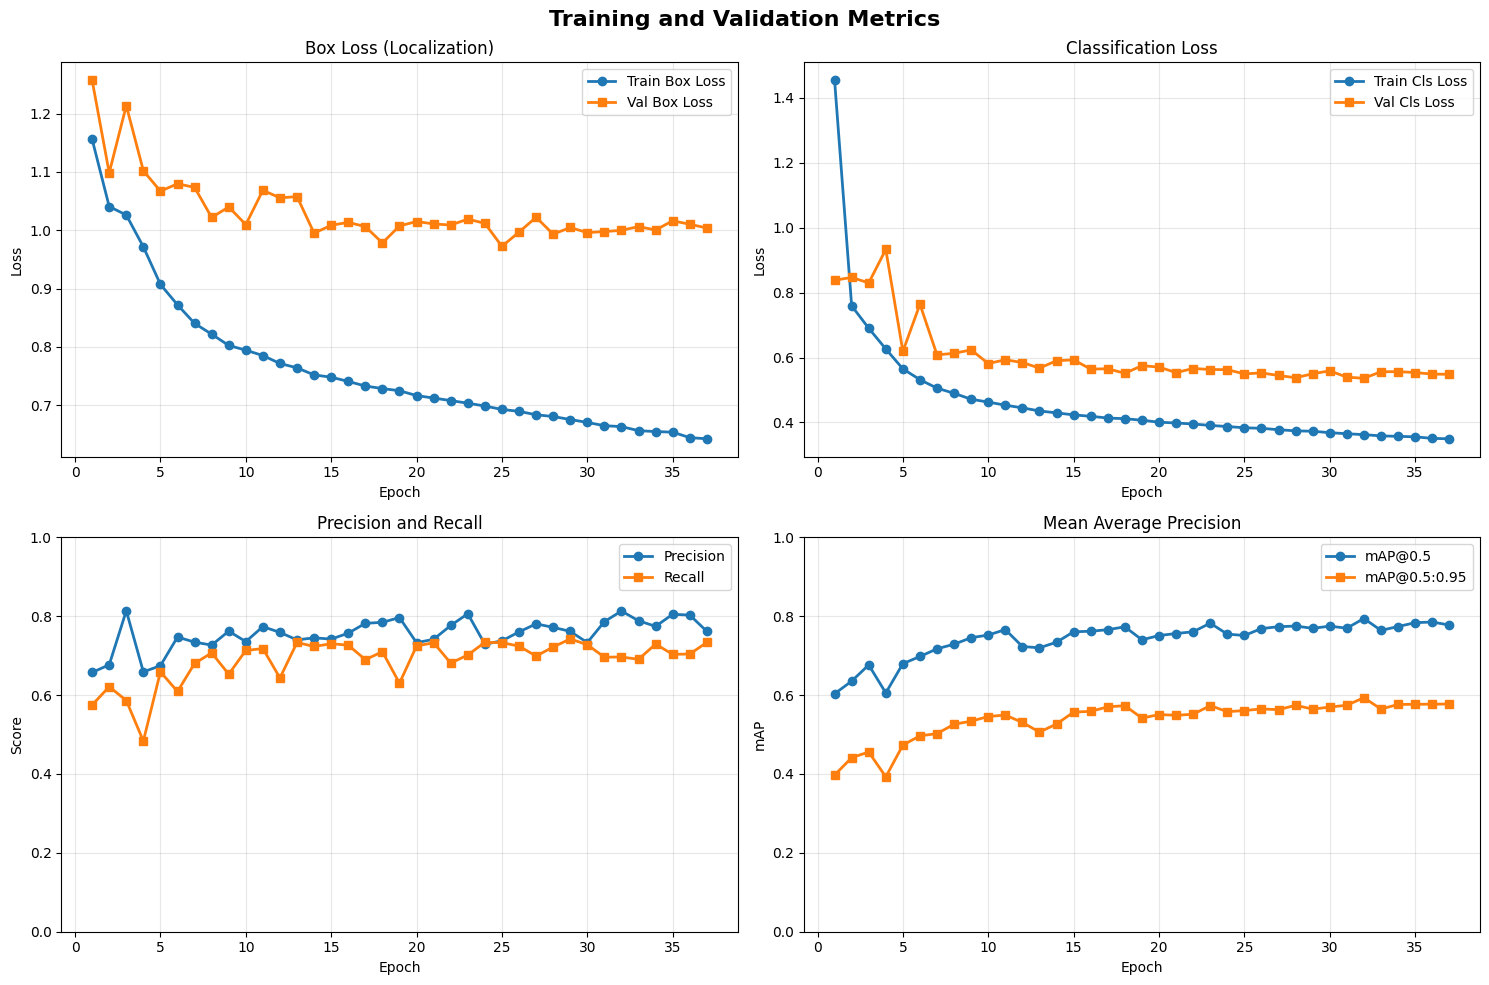

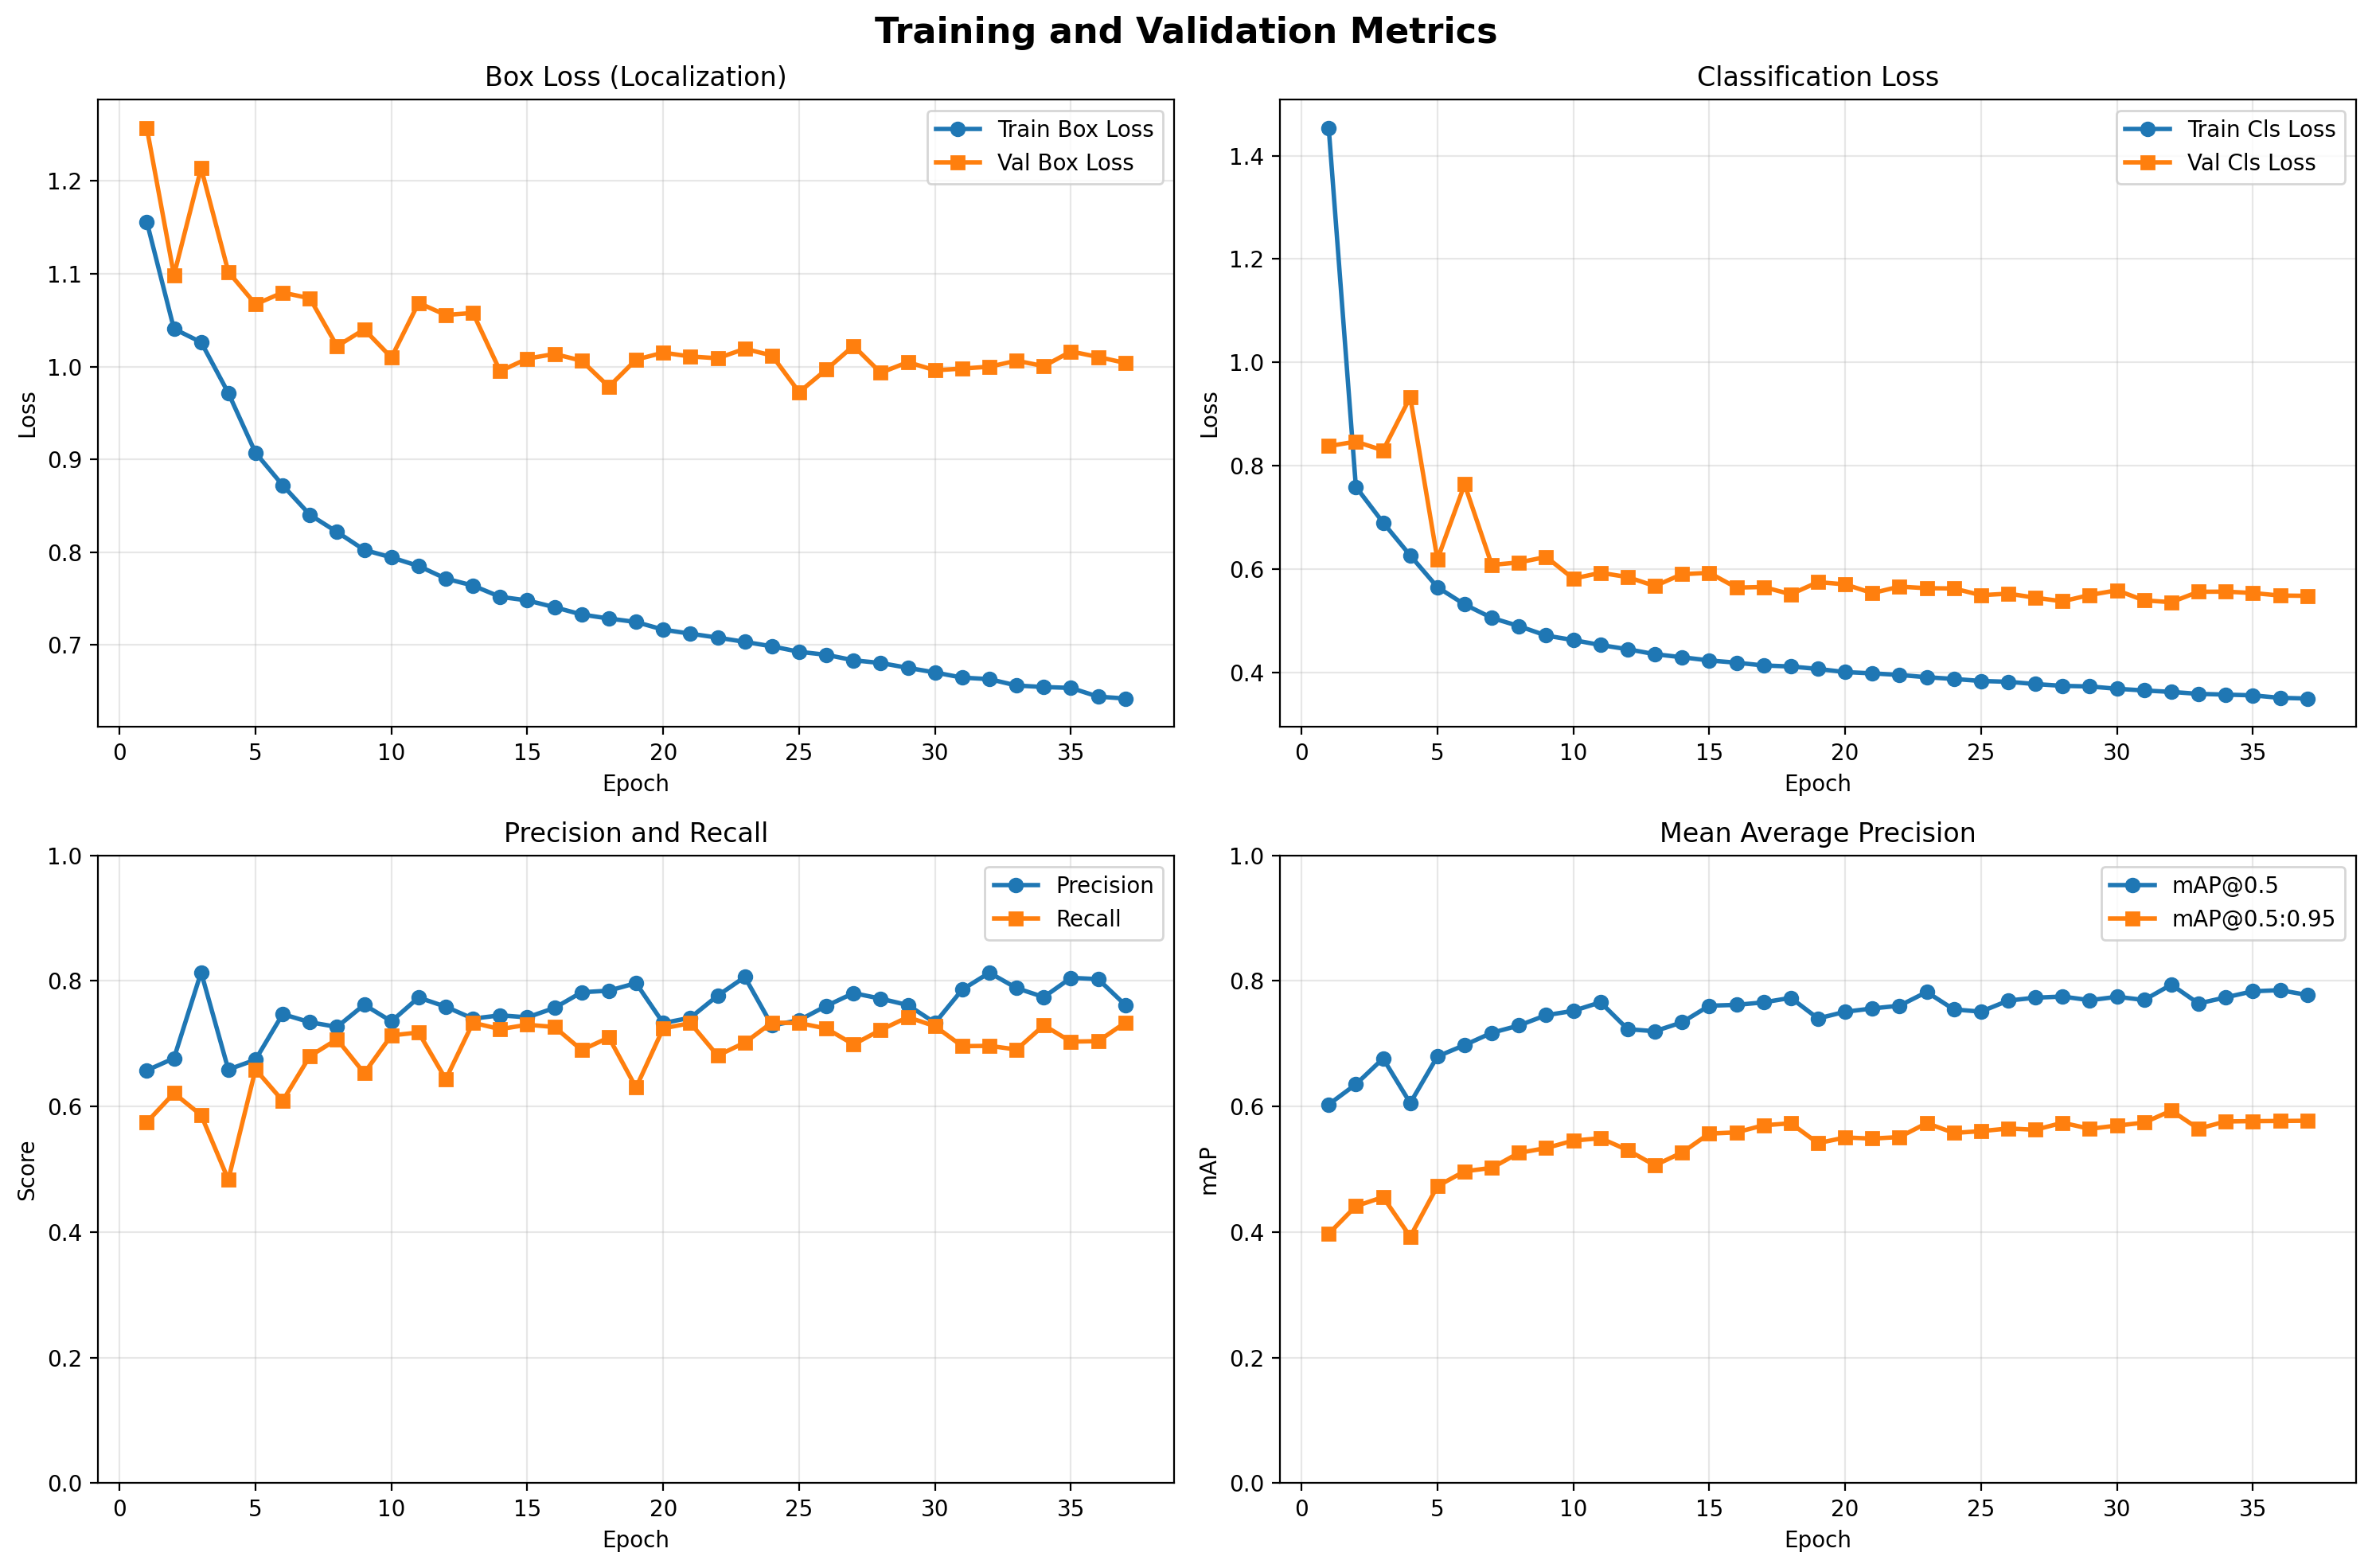


📊 Training Summary:
Total epochs: 37
Best mAP@0.5: 0.7941 (epoch 32)
Final Train Box Loss: 0.6423
Final Val Box Loss: 1.0039


In [4]:
# Training and validation curves

# Get the results CSV path
from IPython.display import Image, display
runs_path = Path(PROJECT_ROOT) / 'runs'
results_csv_path = runs_path /'yolov8n_vehicle_detection2' / 'results.csv'

if results_csv_path.exists():
    # Load training results
    results_df = pd.read_csv(results_csv_path)
    results_df.columns = results_df.columns.str.strip()  # Remove any whitespace from column names
    
    print("Available metrics:")
    print(results_df.columns.tolist())
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Training and Validation Metrics', fontsize=16, fontweight='bold')
    
    # Plot 1: Box Loss (Train vs Val)
    ax = axes[0, 0]
    if 'train/box_loss' in results_df.columns and 'val/box_loss' in results_df.columns:
        ax.plot(results_df.index + 1, results_df['train/box_loss'], label='Train Box Loss', linewidth=2, marker='o')
        ax.plot(results_df.index + 1, results_df['val/box_loss'], label='Val Box Loss', linewidth=2, marker='s')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title('Box Loss (Localization)')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Plot 2: Classification Loss (Train vs Val)
    ax = axes[0, 1]
    if 'train/cls_loss' in results_df.columns and 'val/cls_loss' in results_df.columns:
        ax.plot(results_df.index + 1, results_df['train/cls_loss'], label='Train Cls Loss', linewidth=2, marker='o')
        ax.plot(results_df.index + 1, results_df['val/cls_loss'], label='Val Cls Loss', linewidth=2, marker='s')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title('Classification Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Plot 3: Precision and Recall
    ax = axes[1, 0]
    if 'metrics/precision(B)' in results_df.columns and 'metrics/recall(B)' in results_df.columns:
        ax.plot(results_df.index + 1, results_df['metrics/precision(B)'], label='Precision', linewidth=2, marker='o')
        ax.plot(results_df.index + 1, results_df['metrics/recall(B)'], label='Recall', linewidth=2, marker='s')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Score')
        ax.set_title('Precision and Recall')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1])
    
    # Plot 4: mAP50 and mAP50-95
    ax = axes[1, 1]
    if 'metrics/mAP50(B)' in results_df.columns and 'metrics/mAP50-95(B)' in results_df.columns:
        ax.plot(results_df.index + 1, results_df['metrics/mAP50(B)'], label='mAP@0.5', linewidth=2, marker='o')
        ax.plot(results_df.index + 1, results_df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', linewidth=2, marker='s')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('mAP')
        ax.set_title('Mean Average Precision')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1])
    
    plt.tight_layout()
    
    # Save and display explicitly to ensure rendering in all environments
    fig_dir = Path(PROJECT_ROOT) / 'results' / 'figures'
    fig_dir.mkdir(parents=True, exist_ok=True)
    fig_path = fig_dir / 'training_validation_metrics.png'
    fig.savefig(fig_path, dpi=200, bbox_inches='tight')
    
    plt.show()
    try:
        display(Image(filename=str(fig_path)))
    except Exception as e:
        print(f"Saved figure to {fig_path}")
    
    print("\n📊 Training Summary:")
    print(f"Total epochs: {len(results_df)}")
    print(f"Best mAP@0.5: {results_df['metrics/mAP50(B)'].max():.4f} (epoch {results_df['metrics/mAP50(B)'].idxmax() + 1})")
    print(f"Final Train Box Loss: {results_df['train/box_loss'].iloc[-1]:.4f}")
    print(f"Final Val Box Loss: {results_df['val/box_loss'].iloc[-1]:.4f}")
    
else:
    print(f"❌ Results CSV not found at: {results_csv_path}")
    print("Training must complete first to generate metrics.")